## Explainable Credit Risk Assessment

### Load the Data

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Exploratory Data Analysis (EDA)

In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


-> checking the null values 

In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

-> checking the target column type

In [6]:
df['loan_status'].unique()

array([1, 0])

-> checking class imbalance

In [7]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

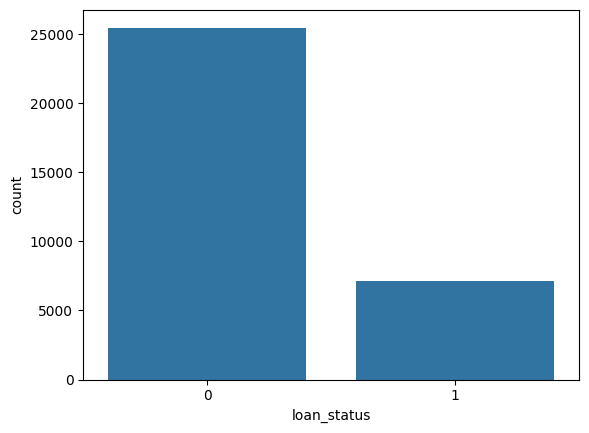

In [8]:
sns.countplot(x='loan_status', data=df)

-> outlier check

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


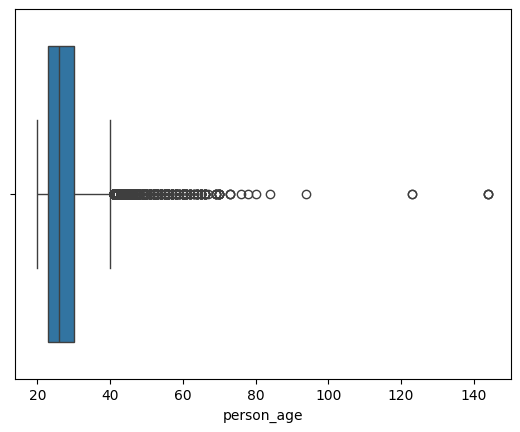

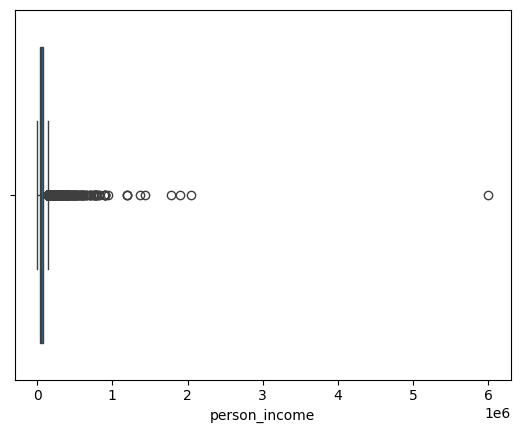

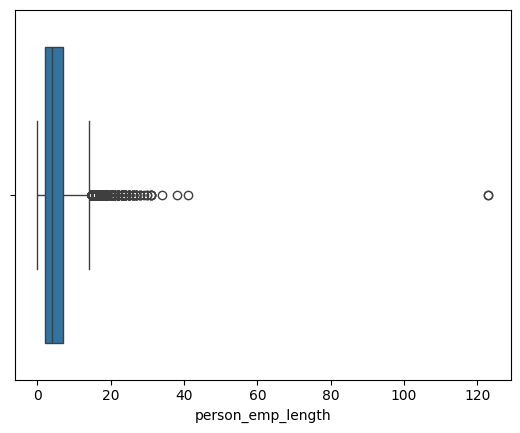

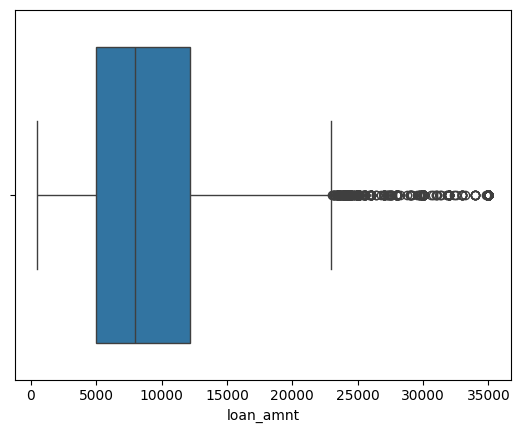

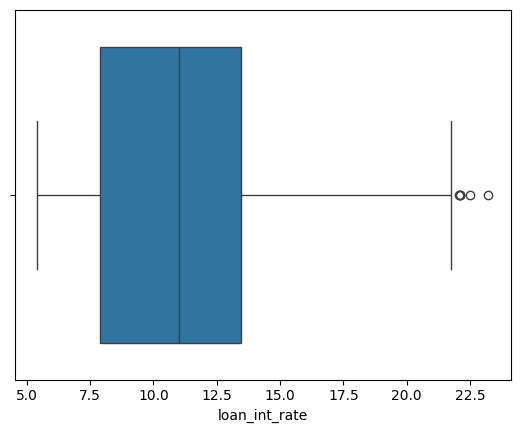

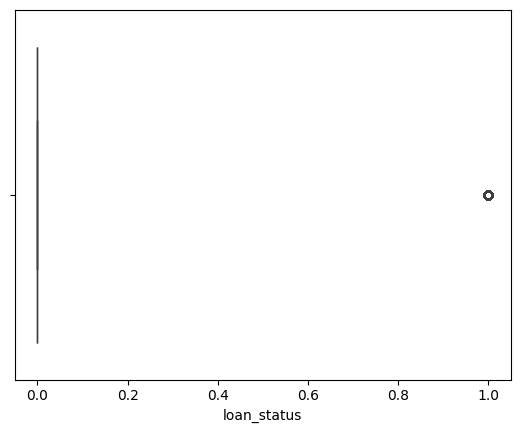

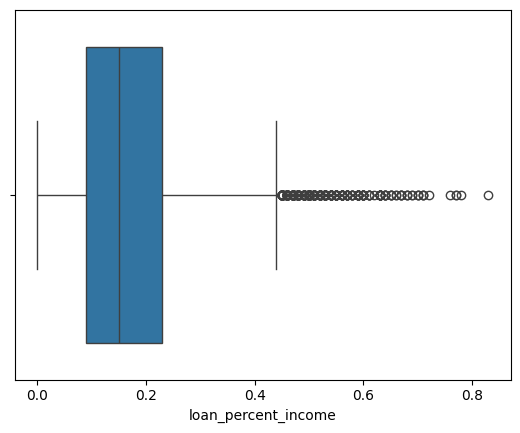

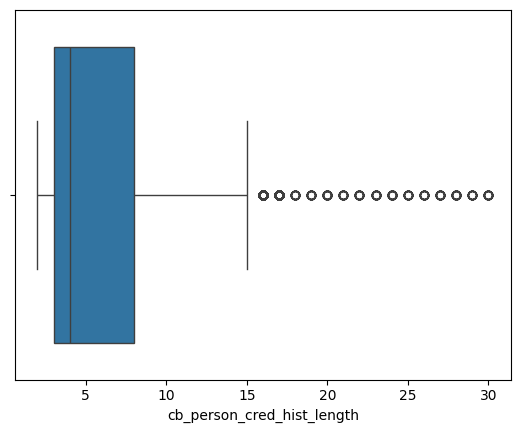

In [10]:
numerical_cols = df.select_dtypes(include=np.number)

for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()
    


In [11]:
(df['person_age'] > 100).sum()

np.int64(5)

In [12]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

-> correlation check

<Axes: >

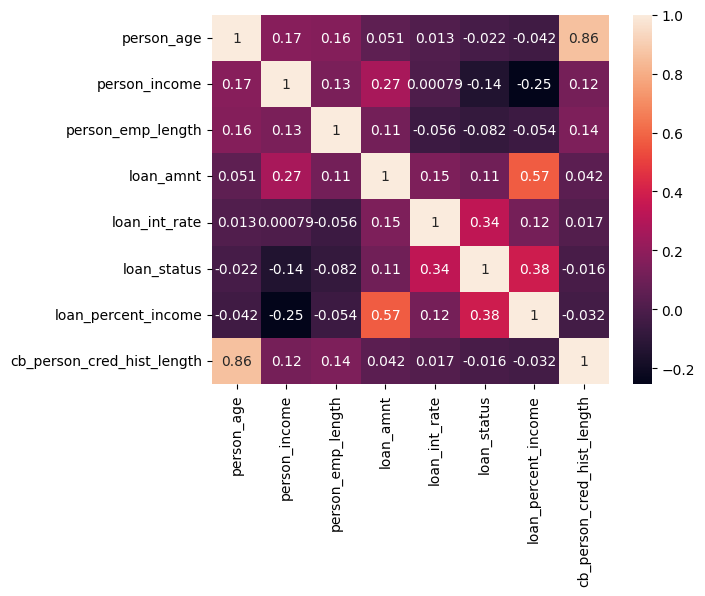

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Data Validation & Outlier Handling

In [14]:
df_copy = df.copy()

print(f"Original shape: {df_copy.shape[0]}")
# remove duplicates rows
df_copy.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df_copy.shape[0]}")

# remove ages below 18 and above 100
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]
print(f"Shape after removing invalid ages: {df_copy.shape[0]}")

# remove employment greater than ages or extreme outliers (> 60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]
print(f"Shape after removing invalid employment lengths: {df_copy.shape[0]}")


# remove the rows with zero and negative income and loan amount
df_copy = df_copy[df_copy['loan_amnt'] > 0]
print(f"Shape after removing invalid loan amounts: {df_copy.shape[0]}")

# check the range of loan interest rate
print("Loan interest rate range from (min : 5.42 and max : 23.22)")

Original shape: 32581
Shape after removing duplicates: 32416
Shape after removing invalid ages: 32411
Shape after removing invalid employment lengths: 31522
Shape after removing invalid loan amounts: 31522
Loan interest rate range from (min : 5.42 and max : 23.22)


In [15]:
df_copy.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,28495.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.045220,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.230786,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Features, Target, & Train-Test Split

In [16]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']


In [17]:
from sklearn.model_selection import train_test_split   

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [18]:
df_copy.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [19]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

### Handle Class imbalance

In [20]:
# Class - weights to handle class imbalance
neg, pos = np.bincount(y_train)
scale_weights = neg / pos
scale_weights

np.float64(3.6306400839454356)

### Data Preprocessing - Pipelines & Column Transfer

-> pipeline for logistic regression

In [21]:
# logistic regression - impute + scale numeric, impute + one-hot encode categorical
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
        
        # Pipeline for categorical columns
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

-> preprocessing for xgboost

In [22]:
# xgboost - impute numeric only (no scaling), impute + one-hot-encoding

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),
        
        # Pipeline for categorical columns
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

-> preprocessing random forest

In [23]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(
                strategy='constant',
                fill_value='missing'
            )),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

### Evaluation Helper Function

In [52]:
# we have to evaluate logistic model & xgboost model on the basis of their metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, classification_report
def evaluate_model(model_name, model, X_test, y_test,threshold=None):
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    if threshold:
        y_pred = (y_pred_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred) # overall model performance
    precision_s = precision_score(y_test, y_pred) # how many of the predicted positive cases are actually positive
    recall_s = recall_score(y_test, y_pred) # how many of the actual positive cases are correctly predicted
    f1_s = f1_score(y_test, y_pred) # harmonic mean of precision and recall
    

    # Confusion matrix 
    cm = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)
    
    
    print(f"Best Threshold: {best_threshold:.2f}")
    print(f"Accuracy Score: {accuracy:.2f}")
    print(f"Precision Score: {precision_s:.2f}")
    print(f"Recall Score: {recall_s:.2f}")
    print(f"F1 Score: {f1_s:.2f}")
    print()
    print(f"{model_name} Classification Report:")
    print(class_report)
    
    
    # plotting confusion matrix
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    
    # plotting roc-auc curve
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.plot(recalls, precisions)
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

### Stratified Cross-Validation

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc' : 'roc_auc', 'accuracy' : 'accuracy', 'precision' : 'precision', 'recall' : 'recall', 'f1' : 'f1' }


In [26]:
# logistic regression
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42,class_weight="balanced"))
])
lr_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
# xgboost
from xgboost import XGBClassifier
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.1, scale_pos_weight=scale_weights, 
        random_state=42
    ))
])
xgb_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Random Forest - Cross Validation Pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
rf_cv_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
for cv_name, pipe in [('logistic regression', lr_cv_pipeline),
                      ('xgboost', xgb_cv_pipeline),
                      ('random forest', rf_cv_pipeline)]:
    cv_results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    print(cv_name)
    print(f"ROC_AUC: {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
    print(f"Precision: {cv_results['test_precision'].mean()}")
    print(f"Recall: {cv_results['test_recall'].mean()}")
    print(f"F1: {cv_results['test_f1'].mean()}")
    print('-'*60)

logistic regression
ROC_AUC: 0.8710636929926183
Accuracy: 0.8117380466802627
Precision: 0.5454408514974111
Recall: 0.7769150052465897
F1: 0.6407615886048793
------------------------------------------------------------
xgboost
ROC_AUC: 0.9461568275418666
Accuracy: 0.9181055970994787
Precision: 0.8193289333324152
Recall: 0.7964323189926548
F1: 0.8076985889182682
------------------------------------------------------------
random forest
ROC_AUC: 0.9279733606681668
Accuracy: 0.9328348062542489
Precision: 0.9723382824467561
Recall: 0.7091290661070304
F1: 0.8200832110763765
------------------------------------------------------------


In [30]:
cv_results

{'fit_time': array([1.12584591, 1.06734157, 1.60617566, 1.5170157 , 2.33576512]),
 'score_time': array([0.1774354 , 0.20773959, 0.46659541, 0.54575181, 0.15207863]),
 'test_roc_auc': array([0.91786949, 0.92616668, 0.92719235, 0.93435485, 0.93428343]),
 'test_accuracy': array([0.92703376, 0.93179243, 0.93428507, 0.9363245 , 0.93473827]),
 'test_precision': array([0.96740741, 0.97109827, 0.97021277, 0.98      , 0.97297297]),
 'test_recall': array([0.68520462, 0.70514166, 0.71773347, 0.71983211, 0.71773347]),
 'test_f1': array([0.8022113 , 0.81702128, 0.82509047, 0.83000605, 0.82608696])}

### Baseline Model - Logistic Regression

In [31]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Accuracy Score: 0.82
Precision Score: 0.55
Recall Score: 0.78
F1 Score: 0.65

Baseline Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88      7415
           1       0.55      0.78      0.65      2042

    accuracy                           0.82      9457
   macro avg       0.74      0.80      0.76      9457
weighted avg       0.85      0.82      0.83      9457



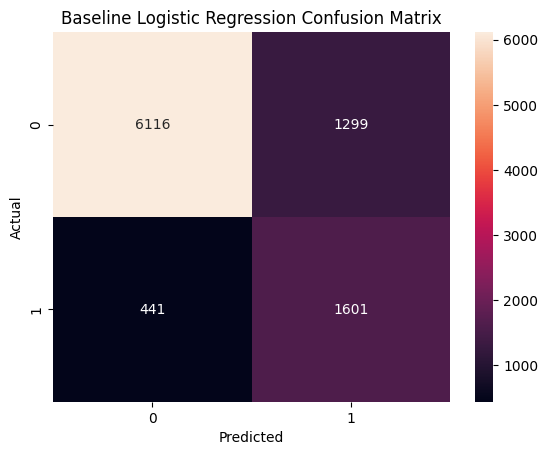

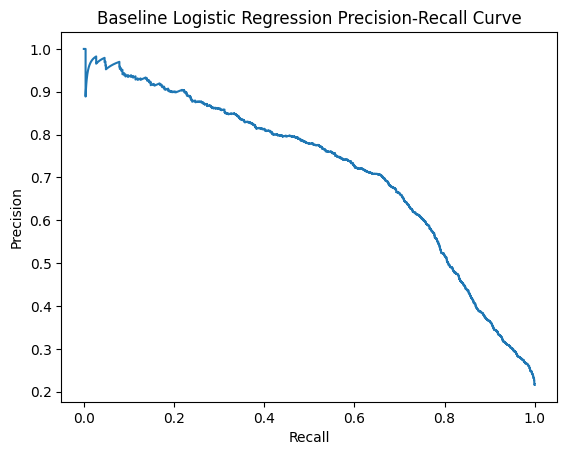

In [32]:
# Evaluation of baseline model
evaluate_model("Baseline Logistic Regression", baseline_model, X_test, y_test)

### XGBoost Hyperparameter Tuning

In [33]:
xg_model = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weights,
        learning_rate=0.1,
        random_state=42
        ))  
])
xg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_grid = {
    "classifier__n_estimators" : randint(150, 600),
    "classifier__max_depth" : randint(3, 9),
    "classifier__learning_rate" :uniform(0.01, 0.5),
    "classifier__colsample_bytree" : uniform(0.6, 0.4),
    "classifier__subsample" : uniform(0.6, 0.4),
    "classifier__min_child_weight" : randint(1, 10),
    "classifier__gamma" : uniform(0, 5)
}

In [35]:
random_search = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter=150,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....0025E638287D0>, 'classifier__gamma': <scipy.stats....0025E63840440>, 'classifier__learning_rate': <scipy.stats....0025E638285F0>, 'classifier__max_depth': <scipy.stats....0025E636651F0>, ...}"
,n_iter,150
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [36]:
print(f"Best score: {random_search.best_score_:.2f}")

Best score: 0.90


In [37]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.7103019852621056),
 'classifier__gamma': np.float64(0.034018195590401756),
 'classifier__learning_rate': np.float64(0.1281260354819973),
 'classifier__max_depth': 4,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 414,
 'classifier__subsample': np.float64(0.9549422069382241)}

### Compare both models side by side

Best Threshold: 1.00
Accuracy Score: 0.82
Precision Score: 0.55
Recall Score: 0.78
F1 Score: 0.65

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88      7415
           1       0.55      0.78      0.65      2042

    accuracy                           0.82      9457
   macro avg       0.74      0.80      0.76      9457
weighted avg       0.85      0.82      0.83      9457



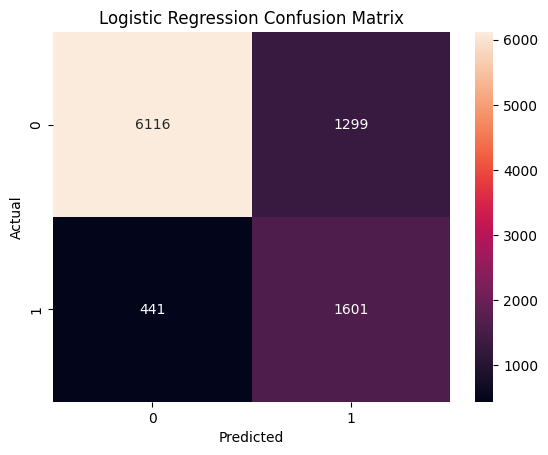

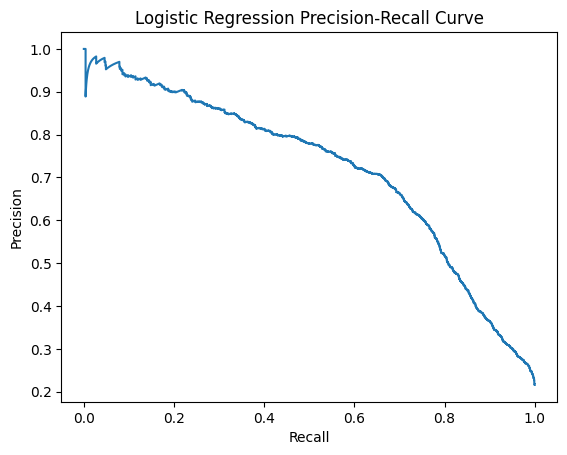

In [59]:
evaluate_model("Logistic Regression", baseline_model, X_test, y_test)

Accuracy Score: 0.91
Precision Score: 0.79
Recall Score: 0.81
F1 Score: 0.80

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7415
           1       0.79      0.81      0.80      2042

    accuracy                           0.91      9457
   macro avg       0.87      0.88      0.87      9457
weighted avg       0.91      0.91      0.91      9457



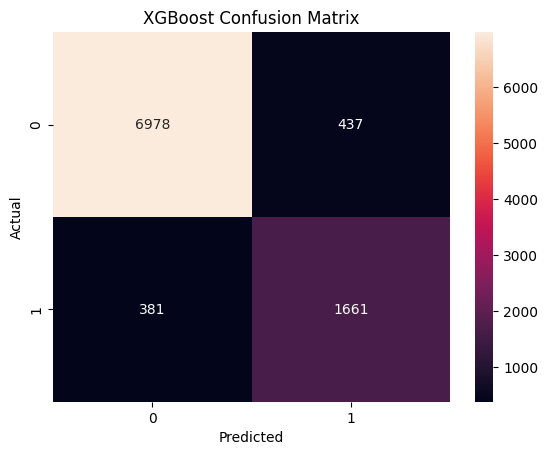

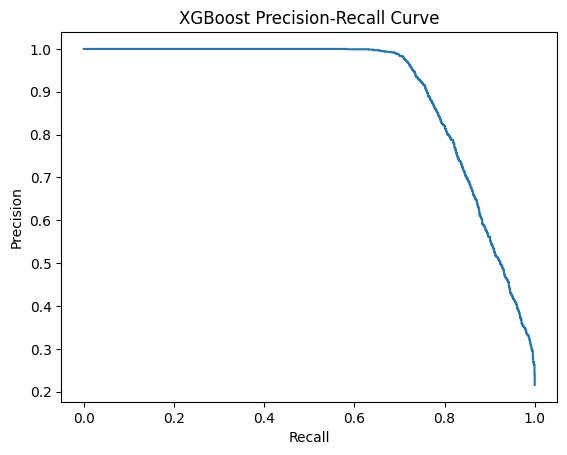

In [39]:
# Passing the xgboost model after performing hyperparameter tuning to the evaluation function to evaluate its performance on the test set.
evaluate_model("XGBoost", random_search, X_test, y_test)

### Random Forest Hyperparameter Tuning

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

In [57]:
from sklearn.model_selection import RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_grid_rf,
    n_iter=15,
    cv=5,
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__class_weight': ['balanced', 'balanced_subsample'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,15
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [58]:
rf_random_search.best_params_

{'classifier__n_estimators': 300,
 'classifier__min_samples_split': 5,
 'classifier__min_samples_leaf': 2,
 'classifier__max_features': None,
 'classifier__max_depth': None,
 'classifier__class_weight': 'balanced_subsample'}

Best Threshold: 1.00
Accuracy Score: 0.93
Precision Score: 0.96
Recall Score: 0.72
F1 Score: 0.82

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7415
           1       0.96      0.72      0.82      2042

    accuracy                           0.93      9457
   macro avg       0.94      0.85      0.89      9457
weighted avg       0.93      0.93      0.93      9457



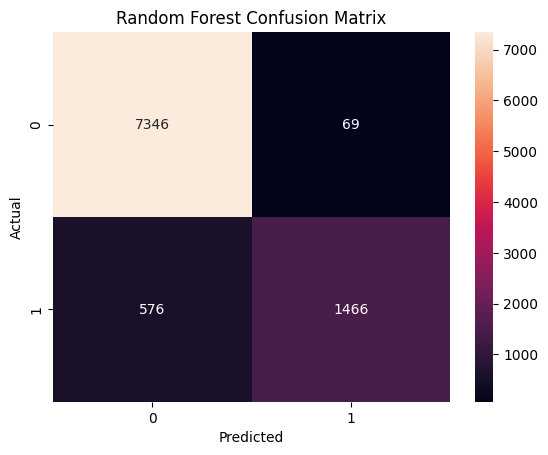

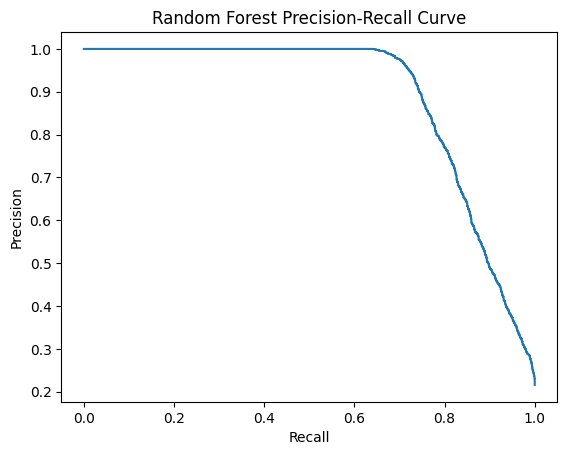

In [60]:
# Passing the random forest model after performing hyperparameter tuning to the evaluation function to evaluate its performance on the test set.
evaluate_model("Random Forest", rf_random_search, X_test, y_test)

### Optimizing the Classification Threshold

Best Threshold: 1.00
Accuracy Score: 0.78
Precision Score: 1.00
Recall Score: 0.00
F1 Score: 0.00

XGBoost with best threshold Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7415
           1       1.00      0.00      0.00      2042

    accuracy                           0.78      9457
   macro avg       0.89      0.50      0.44      9457
weighted avg       0.83      0.78      0.69      9457



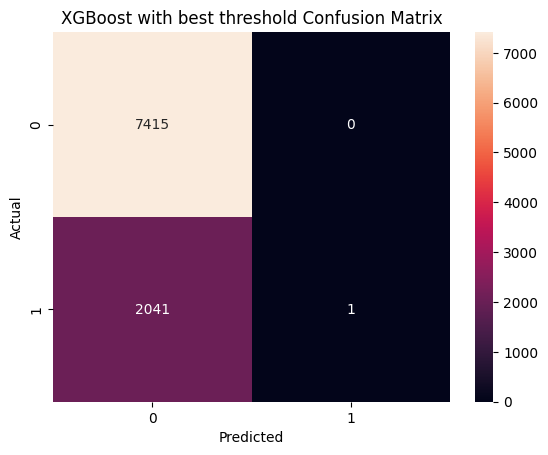

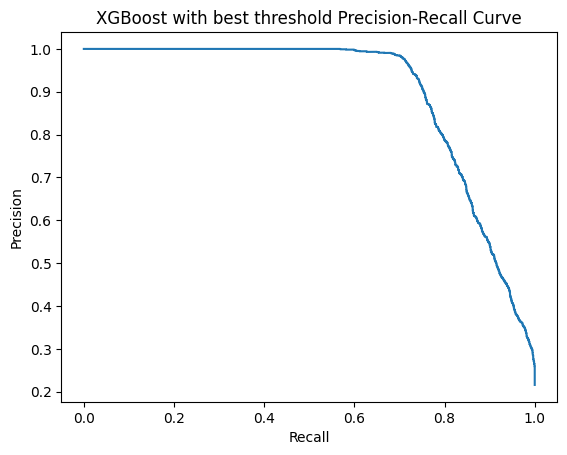

In [53]:
# Get the prob. of class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# From each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 Score for each threshold
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)  # Adding a small value to avoid division by zero

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold
evaluate_model("XGBoost with best threshold", xg_model, X_test, y_test, threshold=best_threshold)

Best Threshold: 1.00
Accuracy Score: 0.79
Precision Score: 1.00
Recall Score: 0.03
F1 Score: 0.05

Random Forest with best threshold Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      7415
           1       1.00      0.03      0.05      2042

    accuracy                           0.79      9457
   macro avg       0.89      0.51      0.47      9457
weighted avg       0.83      0.79      0.70      9457



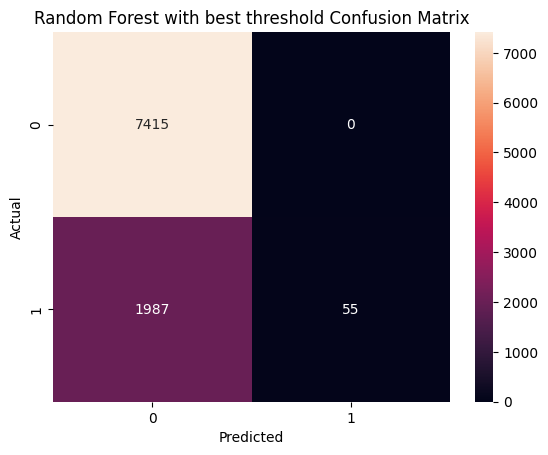

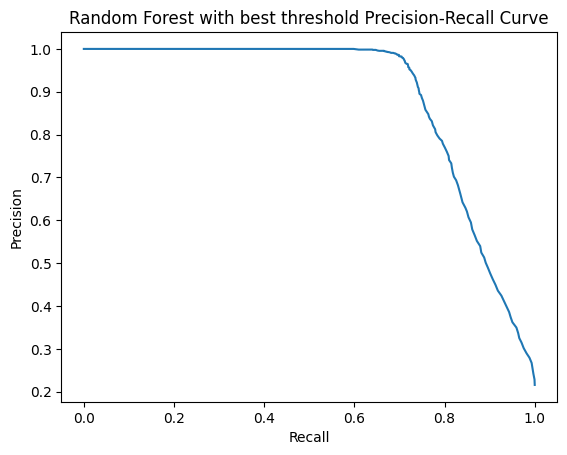

In [54]:
# Get the prob. of class 1 from Random Forest
prob = rf_pipeline.predict_proba(X_test)[:, 1]

# From each threshold calculate Precision and Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate F1 Score for each threshold
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)  # Adding a small value to avoid division by zero

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the XGBoost model using that threshold
evaluate_model("Random Forest with best threshold", rf_pipeline, X_test, y_test, threshold=best_threshold)

### Probability Calibration

-> XGBoost

In [61]:
# 1. Calibrated XGBoost model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
calibrated_model = CalibratedClassifierCV(
    xg_model,
    method='sigmoid',
    cv=5
)

calibrated_model.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [64]:
# 2. Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:, 1]
calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print(uncalibrated)
print(calibrated)

[0.10673105 0.999353   0.15321255 ... 0.10221445 0.14929834 0.29744896]
[0.02465868 0.95941168 0.03108983 ... 0.02370522 0.03840854 0.07473552]


In [65]:
# 3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)


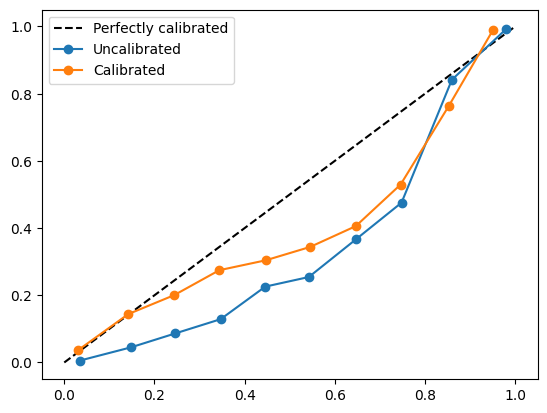

In [72]:
# 4. plot 
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label = 'Perfectly calibrated'
)

plt.plot(
    predicted_uncal, 
    actual_uncal, 
    'o-', 
    label = 'Uncalibrated')

plt.plot(
    predicted_cal, 
    actual_cal, 
    'o-', 
    label = 'Calibrated'
)
plt.legend()

-> Random Forest

In [73]:
# 1. Calibrated random forest model
calibrated_model_rf = CalibratedClassifierCV(
    rf_pipeline,
    method='sigmoid',
    cv=5
)

calibrated_model_rf.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [74]:
# 2. Get probabilities
uncalibrated = rf_pipeline.predict_proba(X_test)[:, 1]
calibrated = calibrated_model_rf.predict_proba(X_test)[:, 1]

print(uncalibrated)
print(calibrated)

[0.02  0.935 0.015 ... 0.01  0.08  0.065]
[0.03759255 0.9825597  0.03594416 ... 0.03057013 0.05482276 0.04058882]


In [75]:
# 3. create calibration curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)


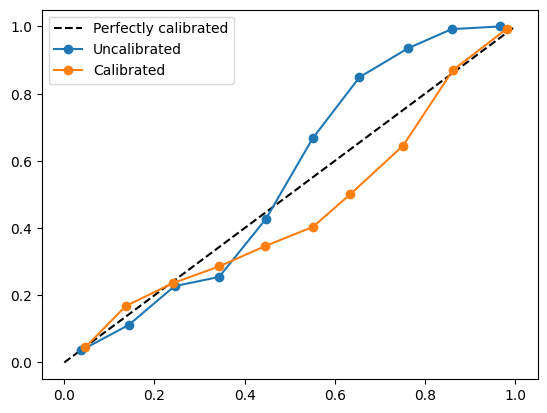

In [76]:
# 4. plot 
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label = 'Perfectly calibrated'
)

plt.plot(
    predicted_uncal, 
    actual_uncal, 
    'o-', 
    label = 'Uncalibrated')

plt.plot(
    predicted_cal, 
    actual_cal, 
    'o-', 
    label = 'Calibrated'
)
plt.legend()

### SHAP Interpretation - Global & Local